# Load the necessary modules

In [1]:
import tifffile
import matplotlib.pyplot as plt
from ganrectf.utils import nor_phase
from ganrectf.ganrec import GANphase

2026-01-09 16:55:01.508163: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-09 16:55:01.562077: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-09 16:55:03.949315: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Set the parameters and read the data

In [2]:
energy = 10
z = 0.5
pv = 5e-7
iter_num = 2000
fname_data = './test_data/hologram_shepp.tiff'
data = tifffile.imread(fname_data)
data = nor_phase(data)

# Reconstruct the phase with GANrec and save the result

I0000 00:00:1767995706.620740   90808 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43491 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:e0:00.0, compute capability: 8.6
I0000 00:00:1767995706.622379   90808 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43685 MB memory:  -> device: 1, name: NVIDIA A40, pci bus id: 0000:e1:00.0, compute capability: 8.6
/nsls2/users/xyang4/ganrec/.pixi/envs/default/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
Reconstruction:   0%|          | 0/2000 [00:00<?, ?it/s]

AttributeError: 'GANphase' object has no attribute 'recon_step'

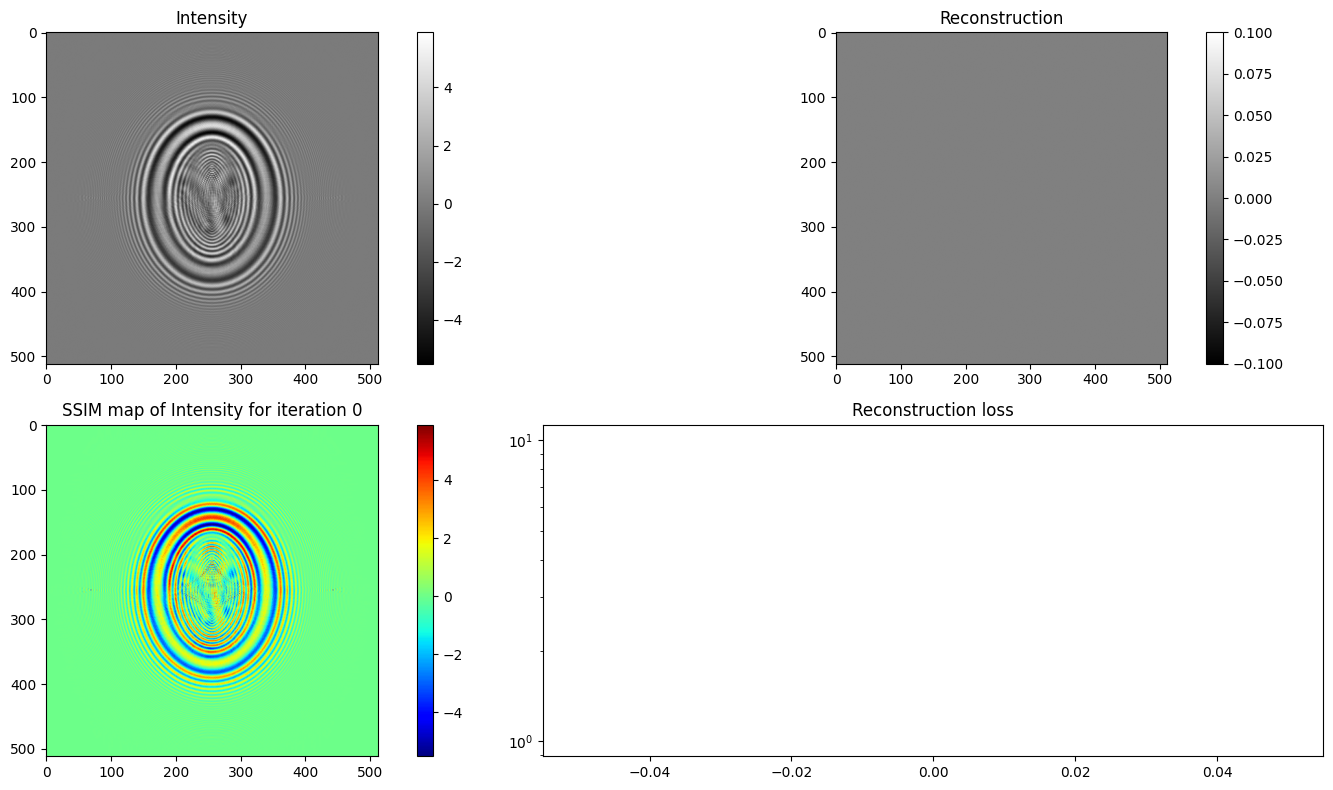

In [3]:
abs, phase = GANphase(data, energy, z, pv, iter_num=iter_num).recon()
plt.imshow(phase)
plt.show()
tifffile.imwrite('./test_results/phase_shepp.tiff', phase)

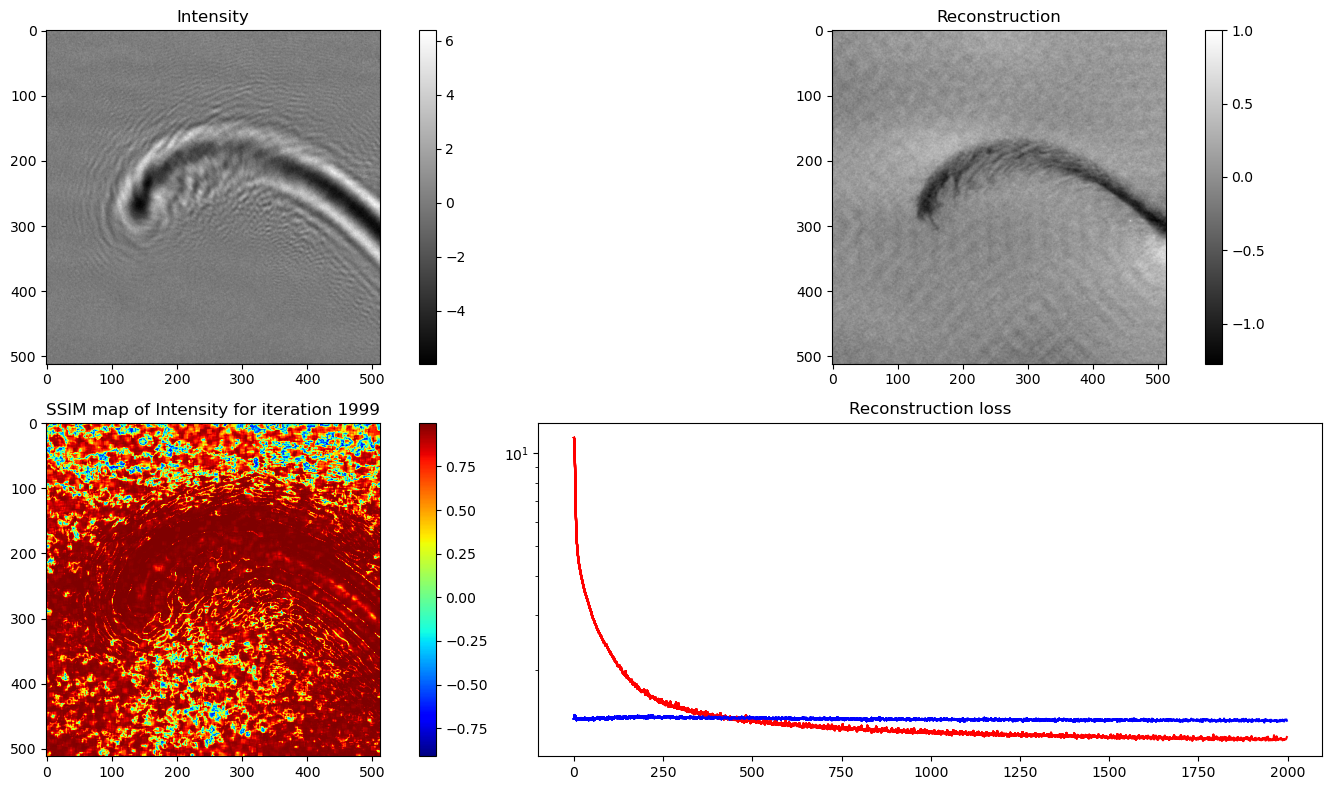

<Figure size 640x480 with 0 Axes>

Reconstruction Progress: 100%|█████████▉| 1999/2000 [01:06<00:00, 34.76it/s, D_loss=1.37, G_loss=1.18]

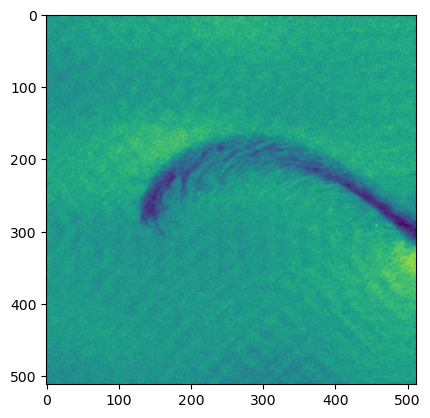

Reconstruction Progress: 100%|██████████| 2000/2000 [01:22<00:00, 34.76it/s, D_loss=1.37, G_loss=1.18]

: 

In [11]:
energy = 11
z = 7.8880960e-2
pv = 1.04735263e-7
abs_ratio = 0.06
iter_num = 2000
g_learning_rate = 1e-3
d_learning_rate = 1e-6
fname_data = './test_data/hologram_spider_hair.tiff'
data = tifffile.imread(fname_data)
data = nor_phase(data)
abs, phase = GANphase(data, energy, z, pv, abs_ratio = abs_ratio, 
                      iter_num=iter_num, 
                      g_learning_rate = g_learning_rate,
                      d_learning_rate = d_learning_rate).recon
plt.imshow(phase)
plt.show()
tifffile.imwrite('./test_results/spider_hair.tiff', phase)